# Teste de treinamento de modelo para predição de Resistência utilizando XGBOOST

### Importação de módulos

In [1]:
%%capture
!pip install xgboost optuna

In [2]:
from sklearn.metrics import r2_score, root_mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
from sklearn.model_selection import GroupKFold, cross_val_score
from xgboost import XGBRegressor
import matplotlib.pyplot as plt
from google.colab import drive
import os, optuna, math
import seaborn as sns
import pandas as pd
import numpy as np

### Montagem do drive

In [3]:
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
dirpath = '/content/drive/MyDrive/supervised-learning-studies/projeto/resistencia'
filename = 'df_resistencia_XGBoost.pkl'
file_path = os.path.join(dirpath, filename)
os.listdir(dirpath)
df = pd.read_pickle(file_path)
df['target'] = df['Resistencia_Compressao_MPa'].copy()
df.drop(inplace=True, columns=['Resistencia_Compressao_MPa'])
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 511 entries, 15 to 598
Data columns (total 14 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   fib_estimativa_base       511 non-null    float64
 1   idade_fator_agua          511 non-null    float64
 2   Massa_Esp_Brita_kg_m3     511 non-null    float64
 3   pow_interacao_tempo       511 non-null    float64
 4   Usa_SP                    511 non-null    bool   
 5   ryshkewitch_cinetico      511 non-null    float64
 6   vol_brita                 511 non-null    float64
 7   Agua_kg_m3                511 non-null    float64
 8   Autores/ano               511 non-null    object 
 9   vol_cimento               511 non-null    float64
 10  vol_filer                 511 non-null    float64
 11  Relacao_Agua_Aglomerante  511 non-null    float64
 12  vol_sp                    511 non-null    float64
 13  target                    511 non-null    float64
dtypes: bool(1), fl

In [5]:
n_groups = df['Autores/ano'].nunique()
print(f"Número de grupos únicos (Autores/ano): {n_groups}")
gkf = GroupKFold(n_splits=n_groups)

Número de grupos únicos (Autores/ano): 17


In [6]:
df.columns

Index(['fib_estimativa_base', 'idade_fator_agua', 'Massa_Esp_Brita_kg_m3',
       'pow_interacao_tempo', 'Usa_SP', 'ryshkewitch_cinetico', 'vol_brita',
       'Agua_kg_m3', 'Autores/ano', 'vol_cimento', 'vol_filer',
       'Relacao_Agua_Aglomerante', 'vol_sp', 'target'],
      dtype='object')

In [7]:
X = df.drop(columns=['target', 'Autores/ano'])
y = df['target']
groups = df['Autores/ano']

all_preds = []
all_true = []
all_groups = []
results = []
importancias_xgb = []

def objective(trial):
    rmse_scores = []

    hyper_params = {
        "booster": "dart", # Mudança estratégica de booster
        "sample_type": "uniform", # Como ele escolhe as árvores para descartar
        "normalize_type": "tree", # Normalização do peso das árvores
        "random_state": 42,
        "eval_metric": "rmse",

        # Parâmetros de Dropout (DART)
        "rate_drop": trial.suggest_float("rate_drop", 0.0, 0.5), # Descarta 10% das árvores (evita vício)
        "n_estimators": trial.suggest_int("n_estimators", 100, 800), # DART é mais lento, não precisa de tantas árvores
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.1),

        # Parâmetros de regularização
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "reg_lambda": trial.suggest_float("reg_lambda", 0.0, 10.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 0.0, 10.0)
    }

    for fold, (train_idx, val_idx) in enumerate(gkf.split(X, y, groups)):
        model = XGBRegressor(**hyper_params)

        X_train = X.iloc[train_idx].copy()
        X_val = X.iloc[val_idx].copy()

        y_train = y.iloc[train_idx].copy()
        y_val = y.iloc[val_idx].copy()

        model.fit(
            X_train,
            y_train,
            eval_set=[(X_train, y_train), (X_val, y_val)],
            verbose=False
        )

        preds = model.predict(X_val)
        eval_results = model.evals_result()
        results.append(eval_results)

        all_preds.extend(preds)
        all_true.extend(y_val)
        all_groups.extend(groups.iloc[val_idx])
        importancias_xgb.append(model.feature_importances_)
        rmse = root_mean_squared_error(y_val, preds)
        rmse_scores.append(rmse)
    return np.mean(rmse_scores)

In [8]:
# ==========================================
# EXECUTANDO O ESTUDO
# ==========================================

# Cria o estudo. A direção é "minimize" porque queremos o menor RMSE possível.
study = optuna.create_study(direction="minimize", study_name="Tuning_DART_Concreto")

# Como o DART demora mais, 30 a 50 trials já trazem resultados fantásticos 
# com a busca bayesiana. (Pode levar alguns minutos)
print("Iniciando a otimização com Optuna...")
study.optimize(objective, n_trials=30)

print("\n" + "="*50)
print("🏆 OTIMIZAÇÃO CONCLUÍDA")
print("="*50)
print(f"Melhor RMSE alcançado (Cross-Validation): {study.best_value:.4f}")
print("Melhores Hiperparâmetros encontrados:")
for key, value in study.best_params.items():
    print(f"  '{key}': {value},")

[I 2026-06-04 15:52:36,048] A new study created in memory with name: Tuning_DART_Concreto


Iniciando a otimização com Optuna...


[W 2026-06-04 16:05:32,118] Trial 0 failed with parameters: {'rate_drop': 0.15600234415761216, 'n_estimators': 758, 'learning_rate': 0.015087141529363572, 'max_depth': 9, 'min_child_weight': 4, 'subsample': 0.7907497487267721, 'colsample_bytree': 0.8654833712104416, 'reg_lambda': 9.244460152804079, 'reg_alpha': 8.349294395349766} because of the following error: KeyboardInterrupt().
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/optuna/study/_optimize.py", line 206, in _run_trial
    value_or_values = func(trial)
                      ^^^^^^^^^^^
  File "/tmp/ipykernel_34038/4046148272.py", line 44, in objective
    model.fit(
  File "/usr/local/lib/python3.12/dist-packages/xgboost/core.py", line 751, in inner_f
    return func(**kwargs)
           ^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/xgboost/sklearn.py", line 1368, in fit
    self._Booster = train(
                    ^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/xg

KeyboardInterrupt: 

In [ ]:
train_curves = []
val_curves = []

for evals_result in results:

    train_curves.append(
        evals_result['validation_0']['rmse']
    )

    val_curves.append(
        evals_result['validation_1']['rmse']
    )

train_curves = np.array(train_curves)
val_curves = np.array(val_curves)

train_mean = train_curves.mean(axis=0)
train_std = train_curves.std(axis=0)

val_mean = val_curves.mean(axis=0)
val_std = val_curves.std(axis=0)

iterations = range(len(train_mean))

plt.figure(figsize=(10, 6))

plt.plot(iterations, train_mean, label='Treino')
plt.plot(iterations, val_mean, label='Validação')

plt.fill_between(
    iterations,
    train_mean - train_std,
    train_mean + train_std,
    alpha=0.2
)

plt.fill_between(
    iterations,
    val_mean - val_std,
    val_mean + val_std,
    alpha=0.2
)

plt.xlabel('Iteração')
plt.ylabel('RMSE')
plt.title('Curva Média de Aprendizado')
plt.legend()
plt.grid(alpha=0.3)

plt.show()

ValueError: setting an array element with a sequence. The requested array has an inhomogeneous shape after 1 dimensions. The detected shape was (540,) + inhomogeneous part.

In [ ]:
# Estatísticas finais
train_final = np.mean(train_curves, axis=0)[-1]
val_final = np.mean(val_curves, axis=0)[-1]
overfitting_gap = val_final - train_final

print("\n" + "="*60)
print("📊 ANÁLISE DE OVERFITTING E PERFORMANCE")
print("="*60)
print(f"✅ RMSE Treino (final):      {train_final:.6f}")
print(f"⚠️  RMSE Validação (final):   {val_final:.6f}")
print(f"📈 Gap (Val - Train):        {overfitting_gap:.6f}")
print("="*60)


📊 ANÁLISE DE OVERFITTING E PERFORMANCE
✅ RMSE Treino (final):      5.149974
⚠️  RMSE Validação (final):   6.665648
📈 Gap (Val - Train):        1.515675


In [ ]:
debug_df = pd.DataFrame({
    'y_true': np.array(all_true).ravel(),
    'y_pred': np.array(all_preds).ravel(),
    'group': np.array(all_groups).ravel()
})

debug_df['residual'] = (
    debug_df['y_true'] - debug_df['y_pred']
)

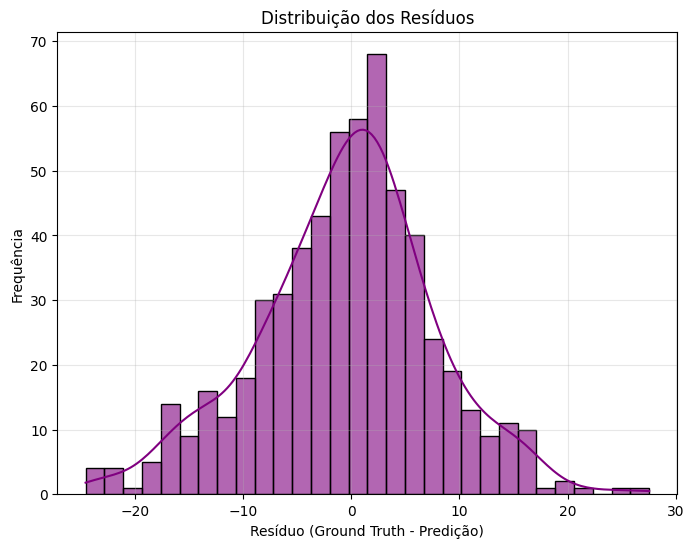

In [ ]:
plt.figure(figsize=(8, 6))

sns.histplot(
    debug_df['residual'],
    bins=30,
    kde=True,
    color='purple',
    alpha=0.6
)

plt.title("Distribuição dos Resíduos")
plt.xlabel("Resíduo (Ground Truth - Predição)")
plt.ylabel("Frequência")

plt.grid(True, alpha=0.3)

plt.show()

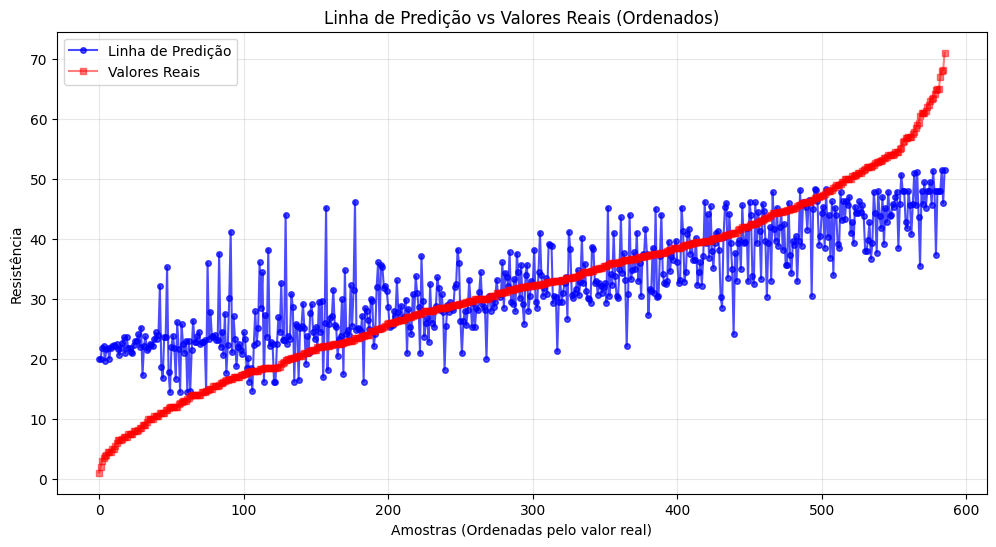

In [ ]:
# Ordenando pelo valor real para a linha de predição não virar um "zigue-zague"
debug_df = debug_df.sort_values(by="y_true").reset_index(drop=True)
indices = range(len(debug_df))

plt.figure(figsize=(12, 6))

# 1. Linha das Predições (conectando os pontos preditos)
plt.plot(indices, debug_df["y_pred"], color='blue', label="Linha de Predição", 
         alpha=0.7, linewidth=1.5, marker='o', markersize=4)

# 2. Pontos dos Valores Reais (Ground Truth)
plt.plot(indices, debug_df["y_true"], color='red', label="Valores Reais", 
            alpha=0.5, linewidth=1.5, marker='s', markersize=4)

plt.title("Linha de Predição vs Valores Reais (Ordenados)")
plt.xlabel("Amostras (Ordenadas pelo valor real)")
plt.ylabel("Resistência")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
r2 = r2_score(debug_df["y_true"], debug_df["y_pred"])
rmse = root_mean_squared_error(debug_df["y_true"], debug_df["y_pred"])
mae = mean_absolute_error(debug_df["y_true"], debug_df["y_pred"])
mape = mean_absolute_percentage_error(debug_df["y_true"], debug_df["y_pred"])

print(f"root_mean_squared_error: {rmse:.4f}")
print(f"mean_absolute_error: {mae:.4f}")
print(f"mean_absolute_percentage_error: {mape:.4f}")
print(f"R² Score: {(r2*100):.4f}")

root_mean_squared_error: 8.2202
mean_absolute_error: 6.2847
mean_absolute_percentage_error: 0.3961
R² Score: 66.4588


In [ ]:
model_path = os.path.join(dirpath, "melhor_modelo_resistencia_XGBOOST.json")
model.save_model(model_path)
print(f"✅ Modelo salvo em: {model_path}")
print(f"\n📋 Informações do Modelo:")
print(f"  • Número de boosting rounds: {model.get_num_boosting_rounds()}")

✅ Modelo salvo em: /content/drive/MyDrive/supervised-learning-studies/projeto/resistencia/melhor_modelo_resistencia_XGBOOST.json

📋 Informações do Modelo:
  • Número de boosting rounds: 500


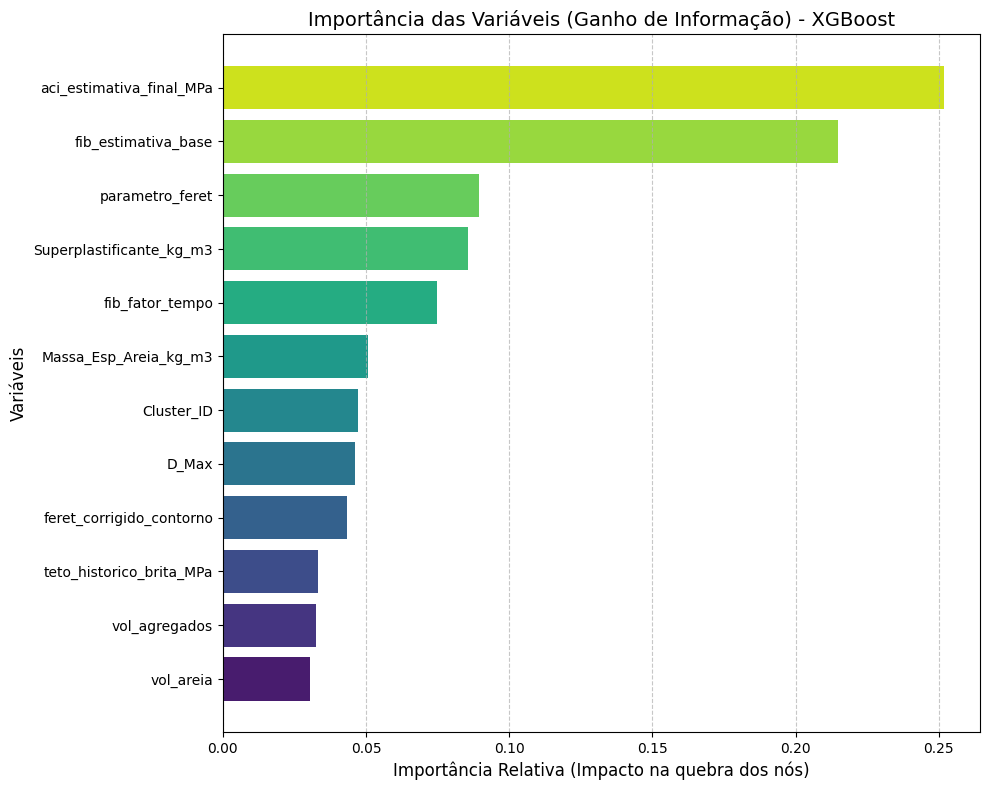

In [ ]:
# 1. Extraindo as importâncias direto do modelo XGBoost treinado
# (Assumindo que o seu modelo se chame 'model_xgb')
importancias_xgb = model.feature_importances_

# 2. Criando o DataFrame para organizar os dados
df_importancia_xgb = pd.DataFrame({
    'Feature': X_train.columns,
    'Importancia': importancias_xgb
})

# Ordenando da maior para a menor importância
df_importancia_xgb = df_importancia_xgb.sort_values(by='Importancia', ascending=True)

# 3. Plotando o Gráfico
plt.figure(figsize=(10, 8))

# Criando uma paleta de cores (usando o 'viridis' para diferenciar do gráfico anterior)
cores = sns.color_palette('viridis', n_colors=len(df_importancia_xgb))

# Plotando as barras horizontais
plt.barh(
    y=df_importancia_xgb['Feature'], 
    width=df_importancia_xgb['Importancia'],
    color=cores,
    edgecolor='none'
)

plt.title('Importância das Variáveis (Ganho de Informação) - XGBoost', fontsize=14)
plt.xlabel('Importância Relativa (Impacto na quebra dos nós)', fontsize=12)
plt.ylabel('Variáveis', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()